In [18]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import os



/Users/davisbrown/opt/anaconda3/envs/trans/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [19]:
def load_and_combine_model_datasets(base_path: str, model_names: list[str]) -> pd.DataFrame:
    """
    Load CSV files for each model and combine them into a single DataFrame with model labels.
    
    Args:
        base_path: Base directory path containing the CSV files
        model_names: List of model names to process
        
    Returns:
        Combined DataFrame with generator model labels
    """
    all_dfs = []
    
    for model in model_names:
        file_path = os.path.join(base_path, f"{model}_dataset.csv")
        try:
            df = pd.read_csv(file_path, index_col=0)
            # Add generator model name as a column
            df['generator_model'] = model
            all_dfs.append(df)
        except FileNotFoundError:
            print(f"Warning: Could not find dataset for {model} at {file_path}")
    
    # Combine all dataframes
    combined_df = pd.concat(all_dfs, ignore_index=True)
    return combined_df

# Load and combine all datasets
base_path = "./"
model_names = ['gpt-4o', 'deepseek-v3', 'llama_8b', 'llama_70b', 'o1_mini', 'sonnet', 'gpt-4o-mini']

combined_df = load_and_combine_model_datasets(base_path, model_names)

In [21]:
combined_df.generator_model.value_counts()

generator_model
gpt-4o         210
o1_mini        210
deepseek-v3    201
llama_70b      201
sonnet         198
llama_8b       186
gpt-4o-mini    186
Name: count, dtype: int64

In [22]:
logical_and_df = combined_df[combined_df.question_type == "P_and_Q"]
logical_and_df.head()

,question_triple_id,iteration,hypothesis,topic,reasoning_flaw,question_type,question_title,question_body,avg_forecast,individual_forecasts,consistency_score,generation_reasoning,generator_model
2,iter4_h2_q1,4,The model overestimates the impact of social m...,Sustainable Fashion,NaN,P_and_Q,Will Patagonia's sales of environmentally-frie...,This question resolves as YES if both conditio...,0.75,"[0.75, 0.75, 0.75, 0.75, 0.75]",0.597867,NaN,gpt-4o
3,iter13_h2_q0,13,The model underestimates the impact of geopoli...,Energy and Geopolitics,NaN,P_and_Q,Will China increase its investment in renewabl...,This question resolves as YES if both conditio...,0.41,"[0.45, 0.35, 0.35, 0.45, 0.45]",0.558942,NaN,gpt-4o
6,iter7_h4_q0,7,The model underestimates the impact of geopoli...,Global Energy Markets,NaN,P_and_Q,Will China increase its investment in renewabl...,This question resolves as YES if both conditio...,0.45,"[0.45, 0.45, 0.45, 0.45, 0.45]",0.544915,NaN,gpt-4o
10,iter7_h1_q1,7,The model overestimates the impact of social m...,Sustainable Fashion,NaN,P_and_Q,Will Patagonia's sales of environmentally-frie...,This question resolves as YES if both conditio...,0.57,"[0.55, 0.55, 0.65, 0.45, 0.65]",0.540032,NaN,gpt-4o
12,iter9_h1_q0,9,The model underestimates the impact of geopoli...,Geopolitics and Energy,NaN,P_and_Q,Will China increase its investment in renewabl...,This question resolves as YES if both conditio...,0.43,"[0.35, 0.45, 0.45, 0.45, 0.45]",0.518487,NaN,gpt-4o


In [5]:
# %pip install --upgrade huggingface_hub==0.27.0 datasets==3.2.0

In [23]:
# # Define topic groupings
# topic_to_group = {
#     # Energy and Environment
#     'energy storage': 'Energy & Environment',
#     'economics and energy': 'Energy & Environment',
#     'energy': 'Energy & Environment',
#     'energy and environment': 'Energy & Environment',
#     'energy policy and sustainability': 'Energy & Environment',
    
#     # Economics
#     'economics': 'Economics',
#     'economics and finance': 'Economics',
    
#     # Politics
#     'geopolitics': 'Politics',
#     'economics and education': 'Politics',
#     'geopolitics and national security': 'Politics',
#     'labor market and technology': 'Politics',
    
#     # Computing
#     'technology and regulation': 'AI & Computer Science',
#     'materials science and quantum computing':  'AI & Computer Science',
#     'cryptography':  'AI & Computer Science',
#     'ai and computing':  'AI & Computer Science',
#     'artificial general intelligence':  'AI & Computer Science',
#     'robotics':  'AI & Computer Science',
#     'ai and robotics':  'AI & Computer Science',
#     'cybersecurity':  'AI & Computer Science',
    
#     #Social Media
#     'social media and politics': 'Media',
#     'social media': 'Media',
#     'social media and regulation': 'Media',
#     'social media and mental health': 'Media',
#     'election misinformation': 'Media',
#     'social media regulation':  'Media',
#     'marketing and e-commerce': 'Media',
#     'elections and misinformation': 'Media',
    
#     # Sports
#     'sports': 'Sports',
#     'sports and olympics': 'Sports'
# }

# def analyze_model_topics(logical_and_df: pd.DataFrame, model_names: list[str]):
#     """
#     Analyze and visualize topic distribution between models using MPNet embeddings and t-SNE.
#     Uses predefined topic groupings for consistent categorization.
#     """
#     # Filter for specified models
#     model_df = logical_and_df[logical_and_df['generator_model'].isin(model_names)]
    
#     # Initialize MPNet model
#     mpnet = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
    
#     # Get embeddings for questions
#     old_texts = model_df['question_body'].tolist()
#     embeddings = mpnet.encode(old_texts, show_progress_bar=True)
#     texts = []
#     for text in old_texts:
#         formatted = ""
#         for i in range(0, len(text), 80):
#             chunk = text[i:i+80]
#             formatted += chunk
#             if i + 80 < len(text):
#                 formatted += "<br>"
#         texts.append(formatted)
    
#     # t-SNE dimensionality reduction
#     tsne = TSNE(n_components=2, perplexity=30, random_state=42)
#     tsne_embeddings = tsne.fit_transform(embeddings)
    
#     # Map topics to groups
#     def get_topic_group(topic):
#         if pd.isna(topic):
#             return 'Other'
#         return topic_to_group.get(topic.lower(), 'Other')
    
#     # Create visualization DataFrame
#     viz_df = pd.DataFrame({
#         'TSNE1': tsne_embeddings[:, 0],
#         'TSNE2': tsne_embeddings[:, 1],
#         'Model': model_df['generator_model'].values,
#         'Question': texts,
#         'Question_Preview': [t[:100] + '...' for t in texts],
#         'Original_Topic': model_df['topic'].values,
#         'Topic_Group': model_df['topic'].apply(get_topic_group)
#     })
    
#     # Define color scheme
# # ... existing code ...

#     # Define color scheme
#     color_map = {
#         'Energy & Environment': '#2ecc71',    # Green
#         'Economics': '#e74c3c',               # Red
#         'Politics': '#3498db',                # Blue
#         'Computing': '#9b59b6',               # Purple
#         'Artificial General Intelligence': '#f1c40f',  # Yellow
#         'Biotechnology': '#1abc9c',           # Turquoise
#         'Sports': '#e67e22',                  # Orange
#         'Other': 'rgba(149, 165, 166, 0.5)'  # Semi-transparent grey
#     }

# # ... existing code ...    
#         # Create interactive plot
#     fig = px.scatter(
#         viz_df,
#         x='TSNE1',
#         y='TSNE2',
#         color='Topic_Group',
#         color_discrete_map=color_map,
#         hover_data={
#             'TSNE1': False,
#             'TSNE2': False,
#             'Model': True,
#             'Original_Topic': True,
#             'Topic_Group': True,
#             'Question_Preview': True
#         },
#         title='Topic Distribution of Adaptive Questions Generated for DeepSeek-V3',
#         height=800,
#         width=2000  # Compressed width
#     )
    
#     # Update layout
#     fig.update_traces(marker=dict(size=15))
#     fig.update_layout(
#         template='plotly_white',
#         legend=dict(
#             title=dict(
#                 text='Question Topics',
#                 font=dict(size=32)  # Increased legend title font size
#             ),
#             yanchor="top",
#             y=1.0,
#             xanchor="left",
#             x=0.02,
#             bgcolor='#fdfbf9',
#             font=dict(size=29),  # Increased legend text font size
#             bordercolor="Black",
#             borderwidth=0
#         ),
#         title=dict(
#             text='', #Topic Distribution of Adaptive Questions Generated for DeepSeek-V3
#             x=0.35,        # Center title horizontally
#             y=0.95,       # Adjust vertical position
#             xanchor='center',  # Anchor point for centering
#             yanchor='top',    # Anchor point for vertical position
#             font=dict(size=20)
#         ),
#         xaxis=dict(
#             title='TSNE1',
#             title_font=dict(size=38),  # Increased axis title font size
#             tickfont=dict(size=1)     # Increased axis tick font size
#         ),
#         yaxis=dict(
#             title='TSNE2',
#             title_font=dict(size=38),  # Increased axis title font size
#             tickfont=dict(size=1)     # Increased axis tick font size
#         ),
#         margin=dict(l=20, r=100, t=50, b=20),
#         plot_bgcolor='#fdfbf9'
#     )
    
#     # Show plot
#     fig.show()
#     fig.write_image("deepseek_v3_topic_distribution.png", 
#                     engine="kaleido",
#                     scale=4.0,  # Increases resolution by 4x
#                     width=2000,  # Base width
#                     height=800)  # Base height
    
#     # Print topic distribution
#     print("\nTopic group distribution by model:")
#     for model in model_names:
#         model_data = viz_df[viz_df['Model'] == model]
#         topic_dist = model_data['Topic_Group'].value_counts()
#         print(f"\n{model} topic distribution:")
#         print(topic_dist)
    
#     return viz_df

# # Run the analysis
# model_names = ['deepseek-v3']
# viz_df = analyze_model_topics(logical_and_df, model_names)

In [24]:
# load in the base huggingface dataset
from datasets import load_dataset

# ds_base = load_dataset("prithvi3/cond_100_test")
# ds_base['test']

# Ps, Qs, PQs = [item['P_body'] for item in ds_base['test']], [item['Q_body'] for item in ds_base['test']], [item['P_and_Q_body'] for item in ds_base['test']]
# # all_questions = [q for triple in zip(Ps, Qs, PQs) for q in triple]

# all_questions = PQs # Ps + Qs

ds_base = load_dataset("prithvi3/consistency_250_test")
PQs = [item['P_and_Q_body'] for item in ds_base['test']]
all_questions = PQs


In [25]:
all_questions[0]

'This question will resolve as **Yes** if both Czechia and Armenia participate in their respective Semi-finals and are officially announced by the European Broadcasting Union (EBU) as having qualified for the Eurovision 2024 Grand Final. If either Czechia or Armenia does not qualify, the question will resolve as **No**.'

In [33]:
def analyze_model_topics_with_unlabeled(
    logical_and_df: pd.DataFrame,
    model_names: list[str],
    all_questions: list[str]
) -> pd.DataFrame:
    """
    Analyze and visualize topic distribution between models (with known topics)
    plus additional unlabeled questions using MPNet embeddings and t-SNE.
    The unlabeled questions are plotted in gray with alpha=0.5,
    but are excluded from the legend.
    """
    import pandas as pd
    import plotly.express as px
    import numpy as np
    from sentence_transformers import SentenceTransformer
    from sklearn.manifold import TSNE
    
    # Filter for specified models
    labeled_df = logical_and_df[logical_and_df['generator_model'].isin(model_names)].copy()
    
    # Build a DataFrame for the unlabeled questions
    unlabeled_df = pd.DataFrame({
        'question_body': all_questions,
        'generator_model': ['Unlabeled'] * len(all_questions),
        'topic': [np.nan] * len(all_questions)
    })
    
    # Combine labeled and unlabeled for a single embedding pass
    combined_df = pd.concat([labeled_df, unlabeled_df], ignore_index=True)
    
    # Initialize MPNet model
    mpnet = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
    
    # Get embeddings for combined questions
    old_texts = combined_df['question_body'].tolist()
    embeddings = mpnet.encode(old_texts, show_progress_bar=True)
    # Add line breaks every 80 chars for plotly hover readability
    texts = []
    for text in old_texts:
        formatted = ""
        for i in range(0, len(text), 80):
            chunk = text[i:i+80]
            formatted += chunk
            if i + 80 < len(text):
                formatted += "<br>"
        texts.append(formatted)
    
    # t-SNE dimensionality reduction
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_embeddings = tsne.fit_transform(embeddings)
    
    # Define topic group mapping
    topic_to_group = {
        # Energy & Environment
        'energy storage': 'Energy & Environment',
        'economics and energy': 'Energy & Environment',
        'energy': 'Energy & Environment',
        'energy and environment': 'Energy & Environment',
        'energy policy and sustainability': 'Energy & Environment',
        
        # Economics
        'economics': 'Economics',
        'economics and finance': 'Economics',
        
        # Politics
        'geopolitics': 'Politics',
        'economics and education': 'Politics',
        'geopolitics and national security': 'Politics',
        'labor market and technology': 'Politics',
        
        # Computing
        'technology and regulation': 'AI & Computer Science',
        'materials science and quantum computing': 'AI & Computer Science',
        'cryptography': 'AI & Computer Science',
        'ai and computing': 'AI & Computer Science',
        'artificial general intelligence': 'AI & Computer Science',
        'robotics': 'AI & Computer Science',
        'ai and robotics': 'AI & Computer Science',
        'cybersecurity': 'AI & Computer Science',
        
        # Social Media
        'social media and politics': 'Media',
        'social media': 'Media',
        'social media and regulation': 'Media',
        'social media and mental health': 'Media',
        'election misinformation': 'Media',
        'social media regulation': 'Media',
        'marketing and e-commerce': 'Media',
        'elections and misinformation': 'Media',
        
        # Sports
        'sports': 'Sports',
        'sports and olympics': 'Sports'
    }
    
    def get_topic_group(topic: str) -> str:
        if pd.isna(topic):
            return 'Unlabeled'
        return topic_to_group.get(topic.lower(), 'Other')
    
    # Construct visualization DataFrame
    combined_viz = pd.DataFrame({
        'TSNE1': tsne_embeddings[:, 0],
        'TSNE2': tsne_embeddings[:, 1],
        'Model': combined_df['generator_model'].values,
        'Question': texts,
        'Topic_Group': combined_df['topic'].apply(get_topic_group)
    })
    
    # Define color map (unlabeled in semi-transparent gray)
    color_map = {
        'Energy & Environment': '#2ecc71',
        'Economics': '#e74c3c',
        'Politics': '#3498db',
        'AI & Computer Science': '#9b59b6',
        'Other': '#95a5a6',
        'Unlabeled': 'rgba(128, 128, 128, 0.2)'
    }
    
    # Create scatter plot
    fig = px.scatter(
        combined_viz,
        x='TSNE1',
        y='TSNE2',
        color='Topic_Group',
        color_discrete_map=color_map,
        hover_data={
            'TSNE1': False,
            'TSNE2': False,
            'Model': True,
            'Topic_Group': True,
            'Question': True
        },
        title='Topic Distribution (with Unlabeled)',
        height=800,
        width=2000
    )
    fig.update_traces(marker=dict(size=15))
    
    # Hide "Unlabeled" in the legend
    for trace in fig.data:
        if trace.name == 'Unlabeled':
            # trace.showlegend = False
            trace.name = 'Static Questions'
        # if trace.name == 'Other':
        #     trace.showlegend = False
    
    # General layout updates
    fig.update_layout(
        template='plotly_white',
        legend=dict(
            title=dict(
                text='Question Topics',
                font=dict(size=32)
            ),
            yanchor="top",
            y=1.0,
            xanchor="right", 
            x=0.98,
            bgcolor='#fdfbf9',
            font=dict(size=29),
            bordercolor="Black",
            borderwidth=0,
            traceorder='normal'  # Ensure 'Unlabeled' appears at the bottom
        ),
        title=dict(
            text='',
            x=0.35,
            y=0.95,
            xanchor='center',
            yanchor='top',
            font=dict(size=20)
        ),
        xaxis=dict(
            title='TSNE1',
            title_font=dict(size=38),
            tickfont=dict(size=1)
        ),
        yaxis=dict(
            title='TSNE2',
            title_font=dict(size=38),
            tickfont=dict(size=1)
        ),
        margin=dict(l=20, r=100, t=50, b=20),
        plot_bgcolor='#fdfbf9'
    )
    
    fig.show()
    fig.write_image(
        "merged_topic_distribution.png",
        engine="kaleido",
        scale=4.0,
        width=2000,
        height=800
    )
    
    # Show topic distribution for labeled models only
    print("\nTopic group distribution (labeled data only):")
    for model in model_names:
        model_data = combined_viz[combined_viz['Model'] == model]
        topic_dist = model_data['Topic_Group'].value_counts()
        print(f"\n{model} topic distribution:")
        print(topic_dist)
    
    return combined_viz

model_names = ['deepseek-v3']
# model_names = ['sonnet']
# model_names = ['gpt-4o']
analyze_model_topics_with_unlabeled(logical_and_df, model_names, all_questions)

Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Topic group distribution (labeled data only):

deepseek-v3 topic distribution:
Topic_Group
AI & Computer Science    14
Sports                   11
Energy & Environment      9
Other                     8
Media                     8
Unlabeled                 7
Economics                 6
Politics                  4
Name: count, dtype: int64


,TSNE1,TSNE2,Model,Question,Topic_Group
0,-7.281897,-21.766138,deepseek-v3,This question resolves as YES if both Sydney M...,Sports
1,-11.933699,-9.033056,deepseek-v3,This question resolves as YES if both the Euro...,Energy & Environment
2,-11.554983,-9.509193,deepseek-v3,This question resolves as YES if both the Euro...,Energy & Environment
3,-11.645167,-9.633681,deepseek-v3,This question resolves as YES if both the Euro...,Energy & Environment
4,-20.496943,2.081941,deepseek-v3,This question resolves as YES if both IBM deve...,AI & Computer Science
...,...,...,...,...,...
312,6.441972,-7.178872,Unlabeled,This question resolves as YES if both of the f...,Unlabeled
313,-8.694863,-1.591284,Unlabeled,This question will be resolved as 'Yes' if bot...,Unlabeled
314,-4.006870,-20.667969,Unlabeled,(a) The question resolves as **Yes** if the at...,Unlabeled
315,-10.402091,-3.661433,Unlabeled,(a) The United Kingdom must hold a general ele...,Unlabeled


In [28]:
def analyze_model_topics_umap_with_unlabeled(
    logical_and_df: pd.DataFrame,
    model_names: list[str],
    all_questions: list[str]
) -> pd.DataFrame:
    """
    Analyze and visualize topic distribution between models (with known topics)
    plus additional unlabeled questions using MPNet embeddings and UMAP.
    The unlabeled questions are plotted in gray with alpha=0.5,
    but are excluded from the legend.
    """
    import pandas as pd
    import plotly.express as px
    import numpy as np
    from sentence_transformers import SentenceTransformer
    from umap import UMAP

    # Filter for specified models
    labeled_df = logical_and_df[logical_and_df['generator_model'].isin(model_names)].copy()

    # Build a DataFrame for the unlabeled questions
    unlabeled_df = pd.DataFrame({
        'question_body': all_questions,
        'generator_model': ['Unlabeled'] * len(all_questions),
        'topic': [np.nan] * len(all_questions)
    })

    # Combine labeled and unlabeled for a single embedding pass
    combined_df = pd.concat([labeled_df, unlabeled_df], ignore_index=True)

    # Initialize MPNet model
    mpnet = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

    # Get embeddings for combined questions
    old_texts = combined_df['question_body'].tolist()
    embeddings = mpnet.encode(old_texts, show_progress_bar=True)
    texts = []
    for text in old_texts:
        formatted = ""
        for i in range(0, len(text), 80):
            chunk = text[i:i+80]
            formatted += chunk
            if i + 80 < len(text):
                formatted += "<br>"
        texts.append(formatted)

    # UMAP dimensionality reduction
    umap_model = UMAP(n_components=2, n_neighbors=15, random_state=42)
    umap_embeddings = umap_model.fit_transform(embeddings)

    # Define topic group mapping
    topic_to_group = {
        # Energy & Environment
        'energy storage': 'Energy & Environment',
        'economics and energy': 'Energy & Environment',
        'energy': 'Energy & Environment',
        'energy and environment': 'Energy & Environment',
        'energy policy and sustainability': 'Energy & Environment',

        # Economics
        'economics': 'Economics',
        'economics and finance': 'Economics',

        # Politics
        'geopolitics': 'Politics',
        'economics and education': 'Politics',
        'geopolitics and national security': 'Politics',
        'labor market and technology': 'Politics',

        # Computing
        'technology and regulation': 'AI & Computer Science',
        'materials science and quantum computing': 'AI & Computer Science',
        'cryptography': 'AI & Computer Science',
        'ai and computing': 'AI & Computer Science',
        'artificial general intelligence': 'AI & Computer Science',
        'robotics': 'AI & Computer Science',
        'ai and robotics': 'AI & Computer Science',
        'cybersecurity': 'AI & Computer Science',

        # Social Media
        'social media and politics': 'Media',
        'social media': 'Media',
        'social media and regulation': 'Media',
        'social media and mental health': 'Media',
        'election misinformation': 'Media',
        'social media regulation': 'Media',
        'marketing and e-commerce': 'Media',
        'elections and misinformation': 'Media',

        # Sports
        'sports': 'Sports',
        'sports and olympics': 'Sports'
    }

    def get_topic_group(topic: str) -> str:
        if pd.isna(topic):
            return 'Static Question'
        return topic_to_group.get(topic.lower(), 'Other')

    # Construct visualization DataFrame
    viz_df = pd.DataFrame({
        'UMAP1': umap_embeddings[:, 0],
        'UMAP2': umap_embeddings[:, 1],
        'Model': combined_df['generator_model'].values,
        'Question': texts,
        'Topic_Group': combined_df['topic'].apply(get_topic_group)
    })

    # Define color scheme, including unlabeled as semi-transparent gray
    color_map = {
        'Energy & Environment': '#2ecc71',  # Green
        'Economics': '#e74c3c',  # Red
        'Politics': '#3498db',  # Blue
        'AI & Computer Science': '#9b59b6',  # Purple
        'Other': '#f39c12',  # Orange
        'Static Question': 'rgba(128, 128, 128, 0.2)'  # Light gray with alpha 0.2
    }

    # Reorder Topic_Group categories to put Static Question last
    topic_order = ['Energy & Environment', 'Economics', 'Politics', 'AI & Computer Science', 'Other', 'Static Question']
    viz_df['Topic_Group'] = pd.Categorical(viz_df['Topic_Group'], categories=topic_order, ordered=True)

    # Create interactive plot
    fig = px.scatter(
        viz_df,
        x='UMAP1',
        y='UMAP2',
        color='Topic_Group',
        color_discrete_map=color_map,
        category_orders={'Topic_Group': topic_order},
        hover_data={
            'UMAP1': False,
            'UMAP2': False,
            'Model': True,
            'Topic_Group': True,
            'Question': True
        },
        title='Topic Distribution (UMAP with Unlabeled)',
        height=800,
        width=2000
    )

    fig.update_traces(marker=dict(size=15))

    # Hide "Unlabeled" in the legend
    for trace in fig.data:
        if trace.name == 'Static Question':
            trace.name = 'Static Questions'
            # trace.showlegend = False

    # General layout updates
    fig.update_layout(
        template='plotly_white',
        legend=dict(
            title=dict(
                text='Question Topics',
                font=dict(size=32)
            ),
            yanchor="top",
            y=1.0,
            xanchor="left",
            x=0.02,
            bgcolor='#fdfbf9',
            font=dict(size=29),
            bordercolor="Black",
            borderwidth=0
        ),
        title=dict(
            text='',
            x=0.35,
            y=0.95,
            xanchor='center',
            yanchor='top',
            font=dict(size=20)
        ),
        xaxis=dict(
            title='UMAP1',
            title_font=dict(size=38),
            tickfont=dict(size=1)
        ),
        yaxis=dict(
            title='UMAP2',
            title_font=dict(size=38),
            tickfont=dict(size=1)
        ),
        margin=dict(l=20, r=100, t=50, b=20),
        plot_bgcolor='#fdfbf9'
    )

    fig.show()

    fig.write_image(
        "merged_topic_distribution_umap.png",
        engine="kaleido",
        scale=4.0,
        width=2000,
        height=800
    )

    # Show topic distribution only for labeled models
    print("\nTopic group distribution (labeled data only):")
    for model in model_names:
        model_data = viz_df[viz_df['Model'] == model]
        topic_dist = model_data['Topic_Group'].value_counts()
        print(f"\n{model} topic distribution:")
        print(topic_dist)

    return viz_df

In [29]:
# Run the analysis
# model_names = ['gpt-4o', 'o1_mini', 'deepseek-v3', 'llama_70b', 'sonnet', 'llama_8b', 'gpt-4o-mini']
model_names = ['deepseek-v3']
# all_questions = Ps + Qs + PQs
# all_questions = PQs
viz_df = analyze_model_topics_umap_with_unlabeled(logical_and_df, model_names, all_questions)


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

/Users/davisbrown/opt/anaconda3/envs/trans/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



Topic group distribution (labeled data only):

deepseek-v3 topic distribution:
Topic_Group
AI & Computer Science    14
Energy & Environment      9
Other                     8
Static Question           7
Economics                 6
Politics                  4
Name: count, dtype: int64


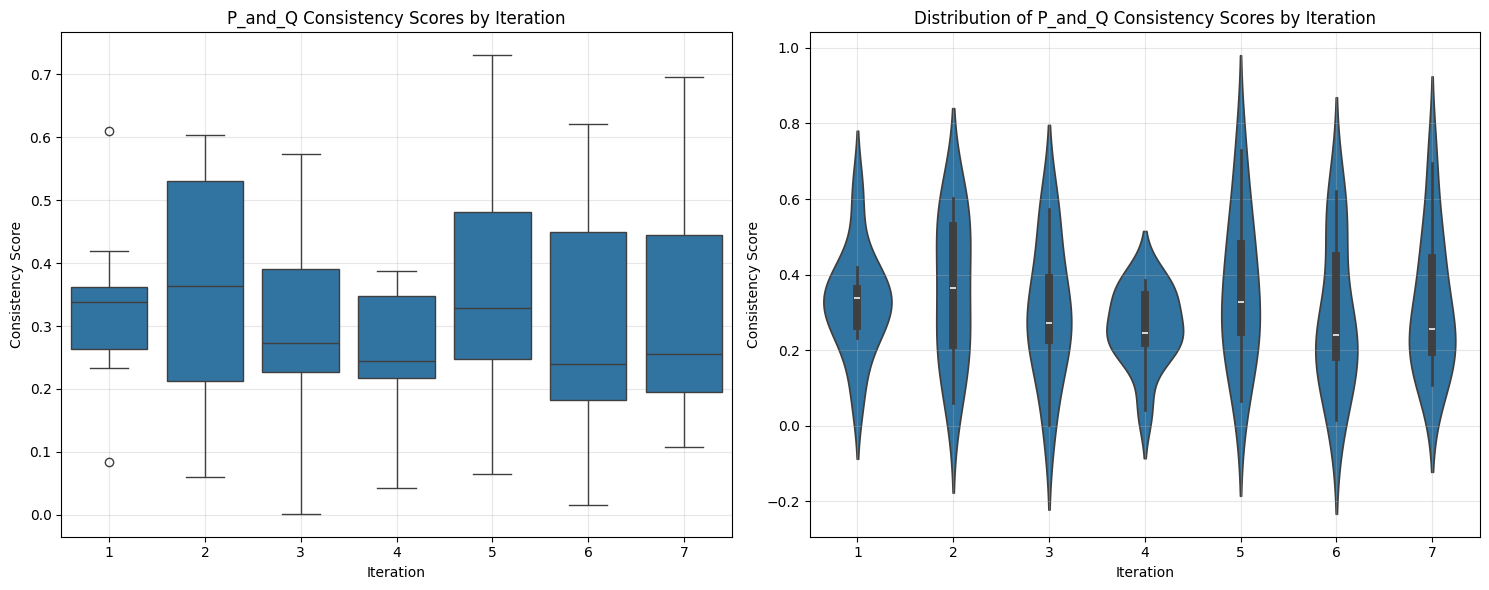


P_and_Q Summary Statistics by Iteration:
           count      mean       std       min       25%       50%       75%  \
iteration                                                                      
1           10.0  0.329256  0.135489  0.083886  0.263225  0.338455  0.361335   
2           10.0  0.358337  0.188363  0.060971  0.213050  0.364316  0.529905   
3           10.0  0.305165  0.177074  0.001749  0.226826  0.272557  0.391345   
4           10.0  0.259834  0.102064  0.043157  0.218147  0.244914  0.347487   
5           10.0  0.360821  0.198456  0.065330  0.248125  0.327948  0.481784   
6           10.0  0.288942  0.197047  0.015881  0.182089  0.239178  0.449601   
7           10.0  0.318892  0.181953  0.107809  0.194483  0.255294  0.444280   

                max  
iteration            
1          0.609836  
2          0.602779  
3          0.572730  
4          0.386702  
5          0.730117  
6          0.620645  
7          0.694979  


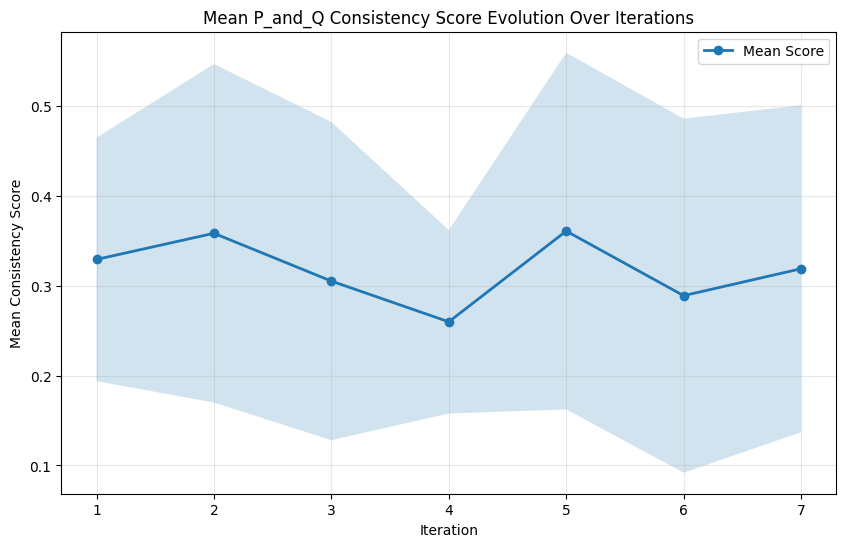

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file
# df = pd.read_csv('deepseek-v3/deepseek_chat_20250127_212346.csv')
df = pd.read_csv('deepseek-v3/deepseek_chat_20250127_124630.csv')

# Filter for only P_and_Q questions and drop duplicates
df_pq = df[df['question_type'] == 'P_and_Q'].drop_duplicates(subset=['question_triple_id'])

# Create a figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Box plot to compare distributions
sns.boxplot(data=df_pq, x='iteration', y='consistency_score', ax=ax1)
ax1.set_title('P_and_Q Consistency Scores by Iteration')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Consistency Score')
ax1.grid(True, alpha=0.3)

# Plot 2: Violin plot to show distribution shapes
sns.violinplot(data=df_pq, x='iteration', y='consistency_score', ax=ax2)
ax2.set_title('Distribution of P_and_Q Consistency Scores by Iteration')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Consistency Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics by iteration
print("\nP_and_Q Summary Statistics by Iteration:")
print(df_pq.groupby('iteration')['consistency_score'].describe())

# Create a line plot showing the trend of mean scores
plt.figure(figsize=(10, 6))
mean_scores = df_pq.groupby('iteration')['consistency_score'].mean()
std_scores = df_pq.groupby('iteration')['consistency_score'].std()

plt.plot(mean_scores.index, mean_scores.values, marker='o', linewidth=2, label='Mean Score')
plt.fill_between(mean_scores.index, 
                 mean_scores.values - std_scores.values,
                 mean_scores.values + std_scores.values,
                 alpha=0.2)

plt.title('Mean P_and_Q Consistency Score Evolution Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Mean Consistency Score')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

/var/folders/gs/b4944zy9317b52hl9zw3rbnh0000gn/T/ipykernel_52577/2879106498.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('iteration').apply(
/var/folders/gs/b4944zy9317b52hl9zw3rbnh0000gn/T/ipykernel_52577/2879106498.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_20_std = df_pq.groupby('iteration').apply(


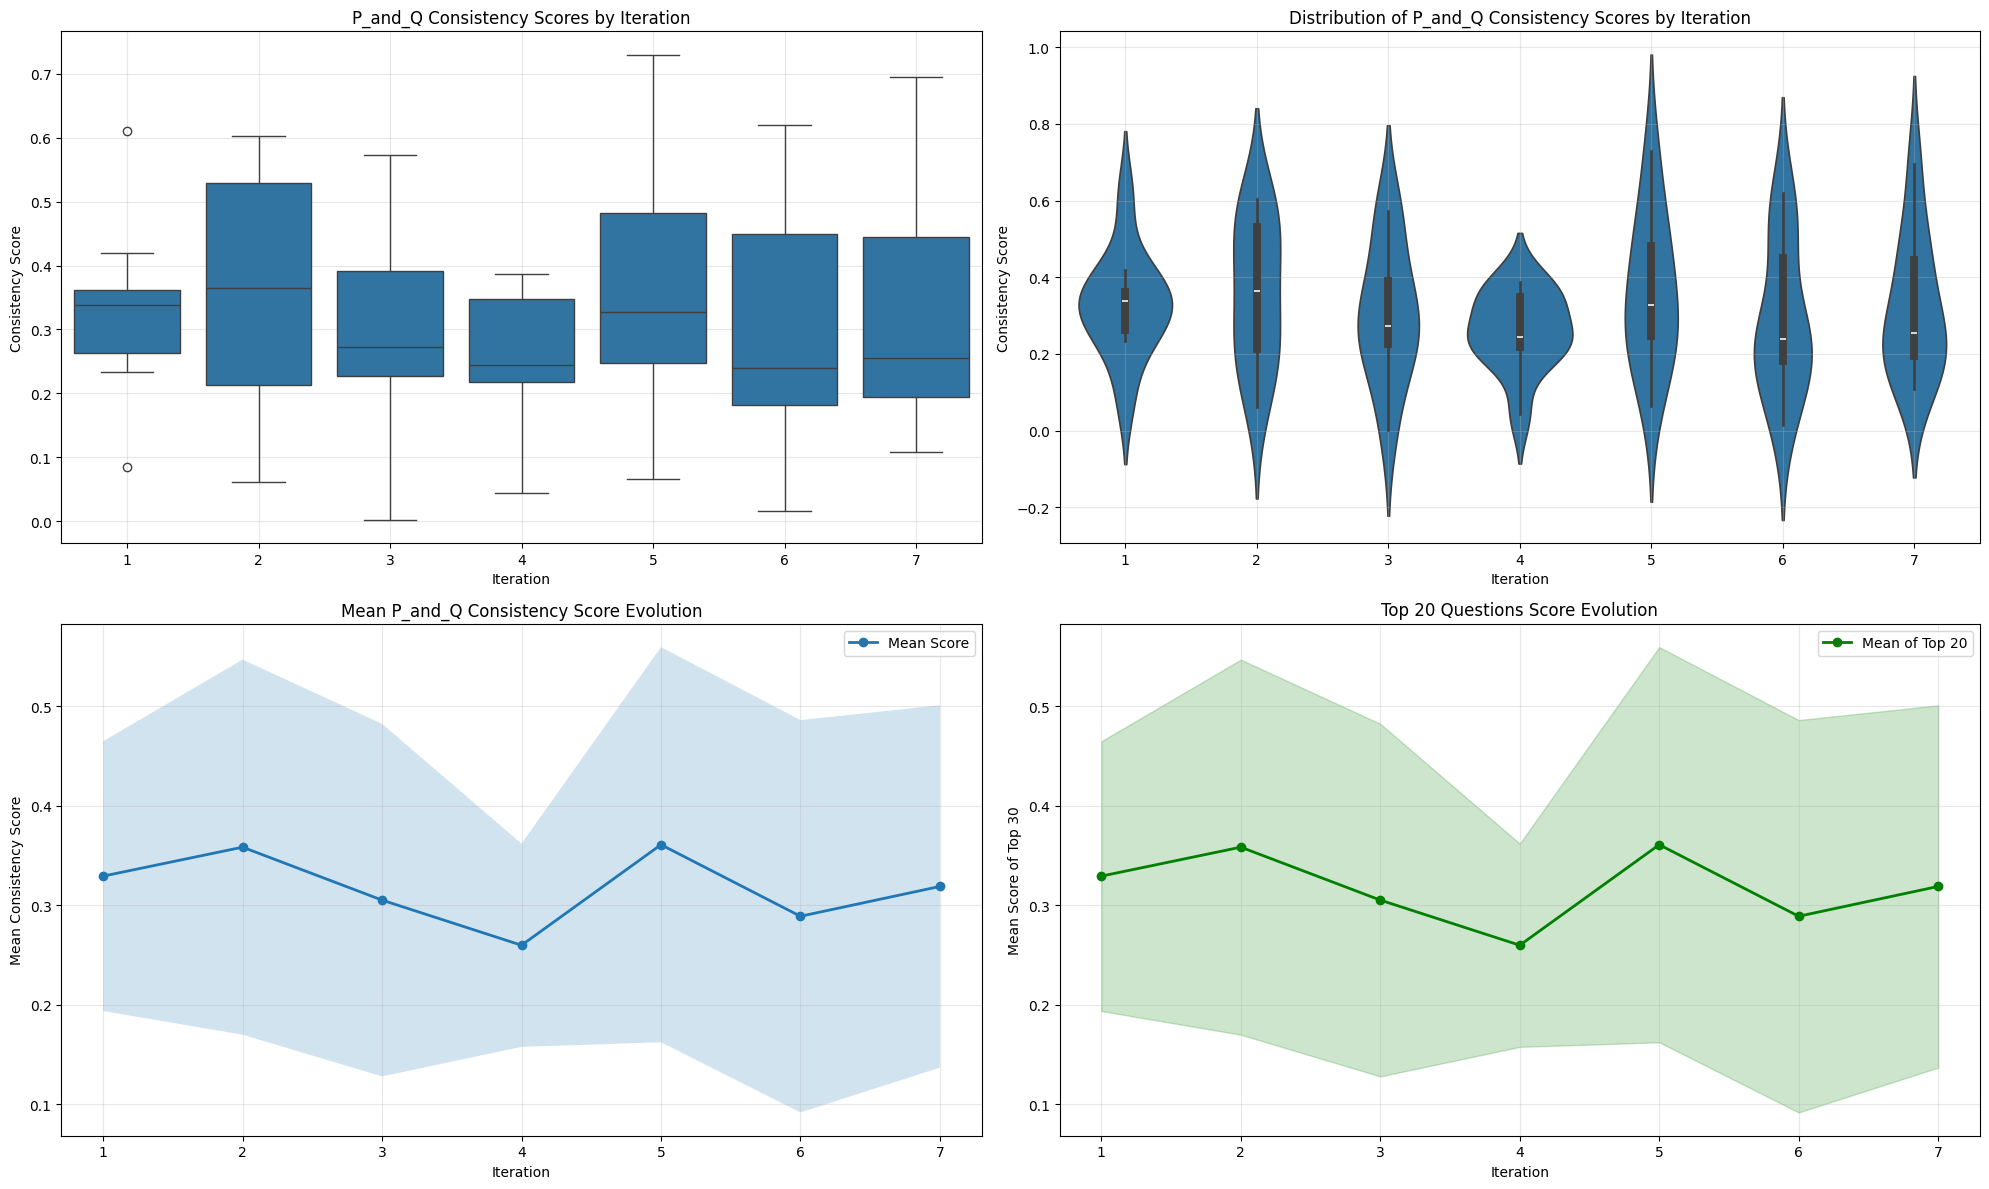


P_and_Q Summary Statistics by Iteration:
           count      mean       std       min       25%       50%       75%  \
iteration                                                                      
1           10.0  0.329256  0.135489  0.083886  0.263225  0.338455  0.361335   
2           10.0  0.358337  0.188363  0.060971  0.213050  0.364316  0.529905   
3           10.0  0.305165  0.177074  0.001749  0.226826  0.272557  0.391345   
4           10.0  0.259834  0.102064  0.043157  0.218147  0.244914  0.347487   
5           10.0  0.360821  0.198456  0.065330  0.248125  0.327948  0.481784   
6           10.0  0.288942  0.197047  0.015881  0.182089  0.239178  0.449601   
7           10.0  0.318892  0.181953  0.107809  0.194483  0.255294  0.444280   

                max  
iteration            
1          0.609836  
2          0.602779  
3          0.572730  
4          0.386702  
5          0.730117  
6          0.620645  
7          0.694979  

Top 20 Questions Summary by Iteration:

In [8]:
df = pd.read_csv('deepseek-v3/deepseek_chat_20250127_124630.csv')

# Filter for only P_and_Q questions and drop duplicates
df_pq = df[df['question_type'] == 'P_and_Q'].drop_duplicates(subset=['question_triple_id'])


# Create a figure with subplots - now 2x2 grid
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Box plot (existing)
sns.boxplot(data=df_pq, x='iteration', y='consistency_score', ax=ax1)
ax1.set_title('P_and_Q Consistency Scores by Iteration')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Consistency Score')
ax1.grid(True, alpha=0.3)

# Plot 2: Violin plot (existing)
sns.violinplot(data=df_pq, x='iteration', y='consistency_score', ax=ax2)
ax2.set_title('Distribution of P_and_Q Consistency Scores by Iteration')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Consistency Score')
ax2.grid(True, alpha=0.3)

# Plot 3: Line plot with mean and std (existing, moved to subplot)
mean_scores = df_pq.groupby('iteration')['consistency_score'].mean()
std_scores = df_pq.groupby('iteration')['consistency_score'].std()

ax3.plot(mean_scores.index, mean_scores.values, marker='o', linewidth=2, label='Mean Score')
ax3.fill_between(mean_scores.index, 
                mean_scores.values - std_scores.values,
                mean_scores.values + std_scores.values,
                alpha=0.2)
ax3.set_title('Mean P_and_Q Consistency Score Evolution')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Mean Consistency Score')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Top 30 questions per iteration
def get_top_n_per_iteration(df, n=30):
    return df.groupby('iteration').apply(
        lambda x: x.nlargest(n, 'consistency_score')['consistency_score'].mean()
    )

top_20_means = get_top_n_per_iteration(df_pq, 20)
top_20_std = df_pq.groupby('iteration').apply(
    lambda x: x.nlargest(20, 'consistency_score')['consistency_score'].std()
)

ax4.plot(top_20_means.index, top_20_means.values, marker='o', linewidth=2, 
         label='Mean of Top 20', color='green')
ax4.fill_between(top_20_means.index,
                top_20_means.values - top_20_std.values,
                top_20_means.values + top_20_std.values,
                alpha=0.2, color='green')
ax4.set_title('Top 20 Questions Score Evolution')
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Mean Score of Top 30')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nP_and_Q Summary Statistics by Iteration:")
print(df_pq.groupby('iteration')['consistency_score'].describe())
print("\nTop 20 Questions Summary by Iteration:")
print(top_20_means)


/var/folders/gs/b4944zy9317b52hl9zw3rbnh0000gn/T/ipykernel_52577/4200311065.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('iteration').apply(
/var/folders/gs/b4944zy9317b52hl9zw3rbnh0000gn/T/ipykernel_52577/4200311065.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_20_std = df_pq.groupby('iteration').apply(


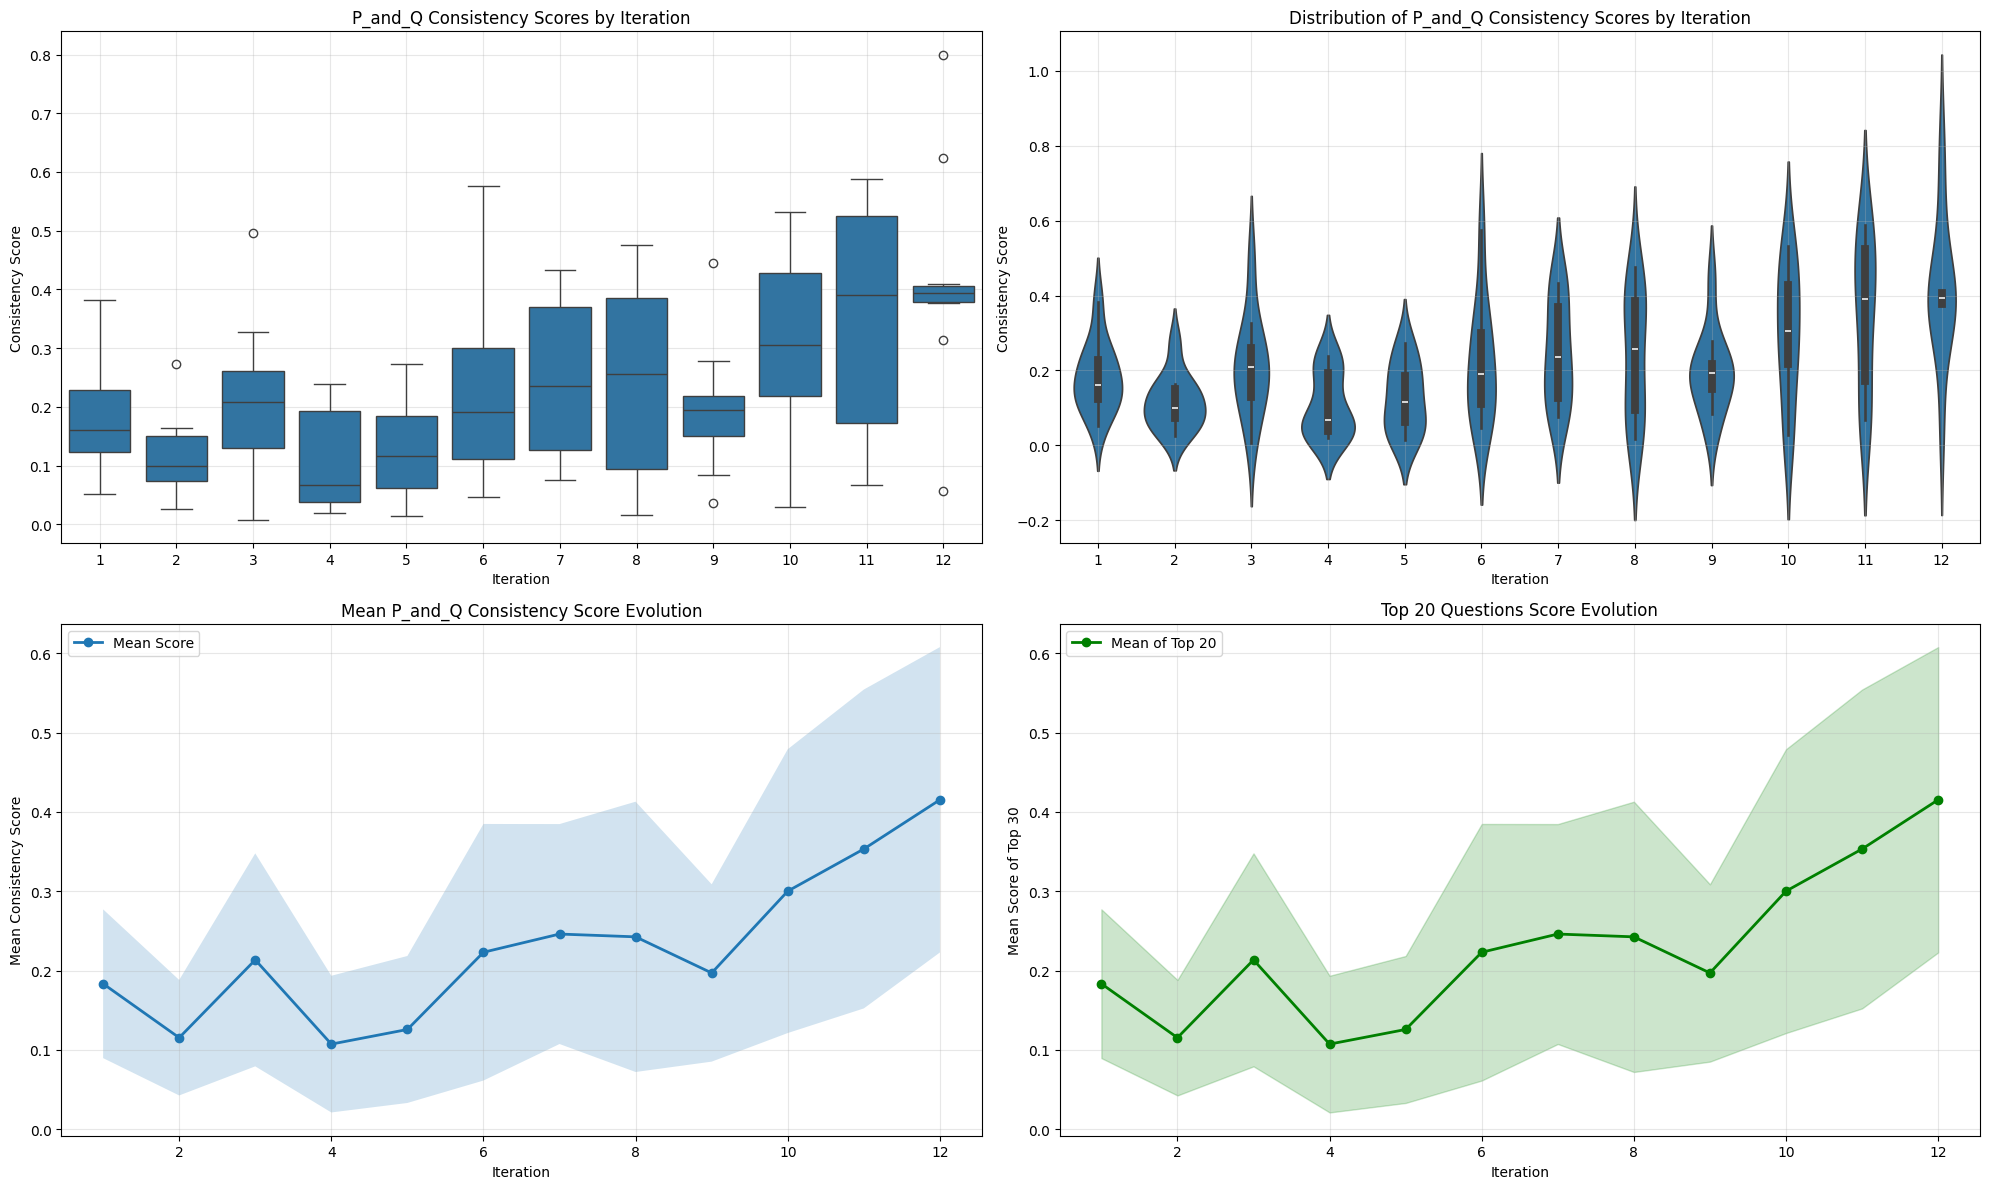


P_and_Q Summary Statistics by Iteration:
           count      mean       std       min       25%       50%       75%  \
iteration                                                                      
1           10.0  0.183404  0.093743  0.050772  0.123073  0.161226  0.227992   
2           10.0  0.115381  0.072777  0.025416  0.073223  0.099903  0.150974   
3           10.0  0.213490  0.134208  0.007292  0.129932  0.208400  0.261056   
4           10.0  0.107310  0.086131  0.019231  0.038667  0.066573  0.193291   
5           10.0  0.125754  0.092618  0.013462  0.062266  0.116888  0.184668   
6           10.0  0.223081  0.161687  0.046296  0.110428  0.190541  0.300740   
7           10.0  0.246030  0.138589  0.075740  0.126946  0.234715  0.370076   
8           10.0  0.242504  0.170330  0.016178  0.093696  0.256552  0.384730   
9           10.0  0.196985  0.111750  0.035393  0.150452  0.193901  0.218606   
10          10.0  0.300118  0.178848  0.028966  0.218164  0.305193  0.427697  

In [17]:

# df = pd.read_csv('sonnet/anthropic_claude_3.5_sonnet_20250127_052908.csv')
# df = pd.read_csv('llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_232333.csv')
df = pd.read_csv('llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv')
# df = pd.read_csv('o1-mini/o1_mini_20250127_042817.csv')
# df = pd.read_csv('o1-mini/o1_mini_20250127_045330.csv')

# Filter for only P_and_Q questions and drop duplicates
df_pq = df[df['question_type'] == 'P_and_Q'].drop_duplicates(subset=['question_triple_id'])

# Create a figure with subplots - now 2x2 grid
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Box plot (existing)
sns.boxplot(data=df_pq, x='iteration', y='consistency_score', ax=ax1)
ax1.set_title('P_and_Q Consistency Scores by Iteration')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Consistency Score')
ax1.grid(True, alpha=0.3)

# Plot 2: Violin plot (existing)
sns.violinplot(data=df_pq, x='iteration', y='consistency_score', ax=ax2)
ax2.set_title('Distribution of P_and_Q Consistency Scores by Iteration')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Consistency Score')
ax2.grid(True, alpha=0.3)

# Plot 3: Line plot with mean and std (existing, moved to subplot)
mean_scores = df_pq.groupby('iteration')['consistency_score'].mean()
std_scores = df_pq.groupby('iteration')['consistency_score'].std()

ax3.plot(mean_scores.index, mean_scores.values, marker='o', linewidth=2, label='Mean Score')
ax3.fill_between(mean_scores.index, 
                mean_scores.values - std_scores.values,
                mean_scores.values + std_scores.values,
                alpha=0.2)
ax3.set_title('Mean P_and_Q Consistency Score Evolution')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Mean Consistency Score')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Top 30 questions per iteration
def get_top_n_per_iteration(df, n=30):
    return df.groupby('iteration').apply(
        lambda x: x.nlargest(n, 'consistency_score')['consistency_score'].mean()
    )

top_20_means = get_top_n_per_iteration(df_pq, 20)
top_20_std = df_pq.groupby('iteration').apply(
    lambda x: x.nlargest(20, 'consistency_score')['consistency_score'].std()
)

ax4.plot(top_20_means.index, top_20_means.values, marker='o', linewidth=2, 
         label='Mean of Top 20', color='green')
ax4.fill_between(top_20_means.index,
                top_20_means.values - top_20_std.values,
                top_20_means.values + top_20_std.values,
                alpha=0.2, color='green')
ax4.set_title('Top 20 Questions Score Evolution')
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Mean Score of Top 30')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nP_and_Q Summary Statistics by Iteration:")
print(df_pq.groupby('iteration')['consistency_score'].describe())
print("\nTop 20 Questions Summary by Iteration:")
print(top_20_means)
